# Project 2 — Mean-Variance Portfolio Optimization

**Spec**
1. Find the optimum (tangency) portfolio of 30 risky assets using the past 10-year excess return as the risk premium.
2. Find the Minimum Variance Portfolio.
3. Compute performance stats for both portfolios assuming monthly rebalancing.
4. Draw the mean-variance frontier.
5. Draw the two-asset frontier for several correlations in [-1, 1].

**Assumptions**
- Window: 2015-01-01 to 2024-12-31 (10 years of daily data).
- Risk-free rate: 2% annual (flat).
- Universe: top 30 S&P 500 constituents by market cap on the first date of the window, restricted to tickers with complete return history over the window (same rule-based selection as Project 1).

## Section 0 — Setup, data, universe, returns

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)

START_DATE = "2015-01-01"
END_DATE = "2024-12-31"
TRADING_DAYS = 252
RF_ANNUAL = 0.02
N_STOCKS = 30

DATA_PATH = "../SPX_database_2010.xlsx"
df_total_ret = pd.read_excel(DATA_PATH, sheet_name="total_ret")
df_price = pd.read_excel(DATA_PATH, sheet_name="prices")
df_mktcap = pd.read_excel(DATA_PATH, sheet_name="mkt_cap")
for _df in (df_total_ret, df_price, df_mktcap):
    _df["Dates"] = pd.to_datetime(_df["Dates"])

In [2]:
# Rule-based universe: top N_STOCKS by market cap on the first date of the window,
# among tickers with a complete non-NaN return history. Same rule as Project 1.
mask_ret = (df_total_ret["Dates"] >= START_DATE) & (df_total_ret["Dates"] <= END_DATE)
df_ret_window = df_total_ret.loc[mask_ret].set_index("Dates")

mask_cap = (df_mktcap["Dates"] >= START_DATE) & (df_mktcap["Dates"] <= END_DATE)
df_cap_window = df_mktcap.loc[mask_cap].set_index("Dates")

valid_tickers = df_ret_window.columns[df_ret_window.notna().all()].tolist()
first_date = df_cap_window.index.min()
caps_at_start = df_cap_window.loc[first_date, valid_tickers].dropna()

selected = caps_at_start.sort_values(ascending=False).head(N_STOCKS).index.tolist()
print(f"Window: {START_DATE} to {END_DATE}")
print(f"Tickers with full history: {len(valid_tickers)}")
print(f"Selected top {N_STOCKS} by market cap on {first_date.date()}:")
for t in selected:
    print(f"  {t}")

Window: 2015-01-01 to 2024-12-31
Tickers with full history: 866
Selected top 30 by market cap on 2015-01-01:
  AAPL UW Equity.1
  AAPL UW Equity
  XOM UN Equity
  XOM UN Equity.1
  MSFT UW Equity
  MSFT UW Equity.1
  BRK/B UN Equity
  BRK/B UN Equity.1
  GOOGL UW Equity.1
  GOOGL UW Equity
  WFC UN Equity.1
  WFC UN Equity
  WMT UN Equity.1
  WMT UN Equity
  GE UN Equity.1
  GE UN Equity
  PG UN Equity
  PG UN Equity.1
  JPM UN Equity.1
  JPM UN Equity
  META UW Equity.1
  META UW Equity
  CVX UN Equity
  CVX UN Equity.1
  ORCL UN Equity.1
  ORCL UN Equity
  PFE UN Equity
  PFE UN Equity.1
  VZ UN Equity
  VZ UN Equity.1


In [3]:
# Simple returns are the canonical input for Markowitz.
df_prices_selected = df_price[["Dates"] + selected]
mask = (df_prices_selected["Dates"] >= START_DATE) & (df_prices_selected["Dates"] <= END_DATE)
df_prices_filtered = df_prices_selected.loc[mask].set_index("Dates")

df_simple_returns = df_prices_filtered.pct_change().dropna()
df_log_returns = np.log(df_prices_filtered / df_prices_filtered.shift(1)).dropna()

print(f"Return panel shape: {df_simple_returns.shape}")
print(df_simple_returns.head())

Return panel shape: (2608, 30)
            AAPL UW Equity.1  AAPL UW Equity  XOM UN Equity  XOM UN Equity.1  \
Dates                                                                          
2015-01-02         -0.009513       -0.009513       0.004110         0.004110   
2015-01-05         -0.028172       -0.028172      -0.027362        -0.027362   
2015-01-06          0.000094        0.000094      -0.005316        -0.005316   
2015-01-07          0.014022        0.014022       0.010133         0.010133   
2015-01-08          0.038422        0.038422       0.016645         0.016645   

            MSFT UW Equity  MSFT UW Equity.1  BRK/B UN Equity  \
Dates                                                           
2015-01-02        0.006674          0.006674        -0.006527   
2015-01-05       -0.009303         -0.009303        -0.014547   
2015-01-06       -0.014571         -0.014571        -0.001088   
2015-01-07        0.012705          0.012705         0.013893   
2015-01-08        

## Section 1 — Tangency (optimum) portfolio

Risk premium = `mu_hat - RF_ANNUAL`, matching the spec's "past 10-year excess return" assumption. We solve long-only max-Sharpe with SLSQP.

In [4]:
mu_hat = df_simple_returns.mean() * TRADING_DAYS
cov_hat = df_simple_returns.cov() * TRADING_DAYS
risk_premium = mu_hat - RF_ANNUAL  # explicit excess-return vector

n = len(selected)
bounds = [(0.0, 1.0)] * n
budget = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
w0 = np.full(n, 1.0 / n)


def neg_sharpe(w, rp, cov):
    vol = np.sqrt(w @ cov.values @ w)
    return -(w @ rp.values) / vol


res_tan = minimize(
    neg_sharpe, w0, args=(risk_premium, cov_hat),
    method="SLSQP", bounds=bounds, constraints=[budget],
    options={"ftol": 1e-10, "maxiter": 500},
)
assert res_tan.success, res_tan.message
w_tan = pd.Series(res_tan.x, index=selected)
assert np.isclose(w_tan.sum(), 1.0)

tan_ret = float(w_tan @ mu_hat)
tan_vol = float(np.sqrt(w_tan @ cov_hat @ w_tan))
tan_sharpe = (tan_ret - RF_ANNUAL) / tan_vol

print("Tangency portfolio (non-zero weights):")
print(w_tan[w_tan > 1e-4].sort_values(ascending=False).round(4))
print(f"\nExpected return:   {tan_ret:.2%}")
print(f"Expected vol:      {tan_vol:.2%}")
print(f"Sharpe (rf={RF_ANNUAL:.0%}): {tan_sharpe:.3f}")

Tangency portfolio (non-zero weights):
MSFT UW Equity       0.1326
MSFT UW Equity.1     0.1326
AAPL UW Equity.1     0.1287
AAPL UW Equity       0.1287
WMT UN Equity        0.1205
WMT UN Equity.1      0.1205
GOOGL UW Equity.1    0.0407
GOOGL UW Equity      0.0407
JPM UN Equity        0.0400
JPM UN Equity.1      0.0400
META UW Equity       0.0375
META UW Equity.1     0.0375
dtype: float64

Expected return:   21.45%
Expected vol:      20.12%
Sharpe (rf=2%): 0.967


## Section 2 — Minimum Variance Portfolio

In [5]:
def port_var(w, cov):
    return w @ cov.values @ w


res_mvp = minimize(
    port_var, w0, args=(cov_hat,),
    method="SLSQP", bounds=bounds, constraints=[budget],
    options={"ftol": 1e-12, "maxiter": 500},
)
assert res_mvp.success, res_mvp.message
w_mvp = pd.Series(res_mvp.x, index=selected)
assert np.isclose(w_mvp.sum(), 1.0)

mvp_ret = float(w_mvp @ mu_hat)
mvp_vol = float(np.sqrt(w_mvp @ cov_hat @ w_mvp))
mvp_sharpe = (mvp_ret - RF_ANNUAL) / mvp_vol

assert mvp_vol < tan_vol, "MVP must have lower volatility than the tangency portfolio."

print("Minimum variance portfolio (non-zero weights):")
print(w_mvp[w_mvp > 1e-4].sort_values(ascending=False).round(4))
print(f"\nExpected return:   {mvp_ret:.2%}")
print(f"Expected vol:      {mvp_vol:.2%}")
print(f"Sharpe (rf={RF_ANNUAL:.0%}): {mvp_sharpe:.3f}")

Minimum variance portfolio (non-zero weights):
VZ UN Equity         0.1178
VZ UN Equity.1       0.1178
PG UN Equity.1       0.1115
PG UN Equity         0.1115
WMT UN Equity        0.0955
WMT UN Equity.1      0.0955
PFE UN Equity.1      0.0586
PFE UN Equity        0.0586
BRK/B UN Equity.1    0.0548
BRK/B UN Equity      0.0548
XOM UN Equity        0.0285
XOM UN Equity.1      0.0285
GOOGL UW Equity      0.0200
GOOGL UW Equity.1    0.0200
META UW Equity.1     0.0076
META UW Equity       0.0076
ORCL UN Equity.1     0.0059
ORCL UN Equity       0.0059
dtype: float64

Expected return:   7.66%
Expected vol:      14.05%
Sharpe (rf=2%): 0.402


## Section 3 — Monthly-rebalanced performance

Each target weight vector is snapped back to the optimal target on the first trading day of each month. Between rebalance dates, dollar weights drift naturally; we approximate this with a month-start reset of the target weights (forward-filled). Portfolio daily simple returns = `(simple_returns * weights_path).sum(axis=1)`.

In [6]:
def first_trading_days(idx, freq):
    s = pd.Series(idx, index=idx)
    return pd.DatetimeIndex(s.resample(freq).first().dropna().values)


first_days_1m = first_trading_days(df_simple_returns.index, "MS")


def build_weight_path(target_weights, rebal_dates, full_index):
    """Snap the static target back on every rebalance date and forward-fill to daily."""
    frame = pd.DataFrame(
        np.tile(target_weights.values, (len(rebal_dates), 1)),
        index=rebal_dates,
        columns=target_weights.index,
    )
    path = frame.reindex(full_index, method="ffill").ffill()
    assert not path.isna().any().any(), "weight path has NaNs"
    return path


w_tan_path = build_weight_path(w_tan, first_days_1m, df_simple_returns.index)
w_mvp_path = build_weight_path(w_mvp, first_days_1m, df_simple_returns.index)

# Rebalance-date check: path equals target exactly on rebalance days.
assert np.allclose(w_tan_path.loc[first_days_1m].values, w_tan.values)
assert np.allclose(w_mvp_path.loc[first_days_1m].values, w_mvp.values)

tan_daily = (df_simple_returns * w_tan_path).sum(axis=1)
mvp_daily = (df_simple_returns * w_mvp_path).sum(axis=1)
assert len(tan_daily) == len(df_simple_returns)


def portfolio_stats(r, rf=RF_ANNUAL):
    n_days = len(r)
    ann_return = (1.0 + r).prod() ** (TRADING_DAYS / n_days) - 1.0
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan
    return {"Annualized Return": ann_return,
            "Annualized Volatility": ann_vol,
            "Sharpe Ratio": sharpe}


stats_df = pd.DataFrame({
    "Tangency": portfolio_stats(tan_daily),
    "Min Variance": portfolio_stats(mvp_daily),
}).T
print("Realized performance (monthly rebalancing, 2015–2024):")
print(stats_df.to_string(formatters={
    "Annualized Return": "{:.2%}".format,
    "Annualized Volatility": "{:.2%}".format,
    "Sharpe Ratio": "{:.3f}".format,
}))

Realized performance (monthly rebalancing, 2015–2024):
             Annualized Return Annualized Volatility Sharpe Ratio
Tangency                21.43%                20.12%        0.966
Min Variance             6.90%                14.05%        0.348


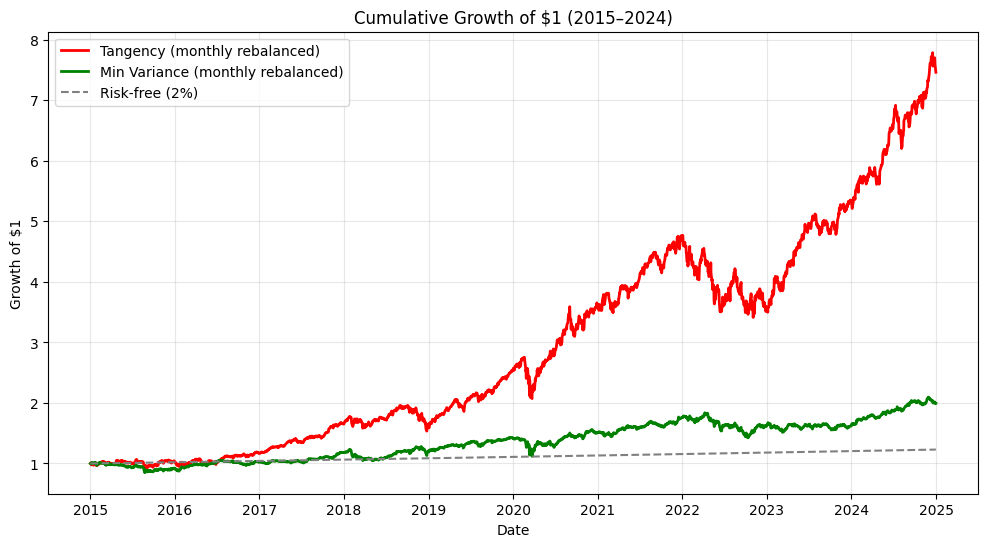

In [7]:
tan_growth = (1.0 + tan_daily).cumprod()
mvp_growth = (1.0 + mvp_daily).cumprod()
rf_growth = pd.Series(
    (1.0 + RF_ANNUAL / TRADING_DAYS) ** np.arange(len(tan_daily)),
    index=tan_daily.index, name="Risk-Free",
)

plt.figure(figsize=(12, 6))
plt.plot(tan_growth.index, tan_growth, label="Tangency (monthly rebalanced)", color="red", linewidth=2)
plt.plot(mvp_growth.index, mvp_growth, label="Min Variance (monthly rebalanced)", color="green", linewidth=2)
plt.plot(rf_growth.index, rf_growth, label=f"Risk-free ({RF_ANNUAL:.0%})", color="gray", linestyle="--")
plt.title("Cumulative Growth of $1 (2015–2024)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Section 4 — Mean-variance frontier (30 assets) + Capital Market Line

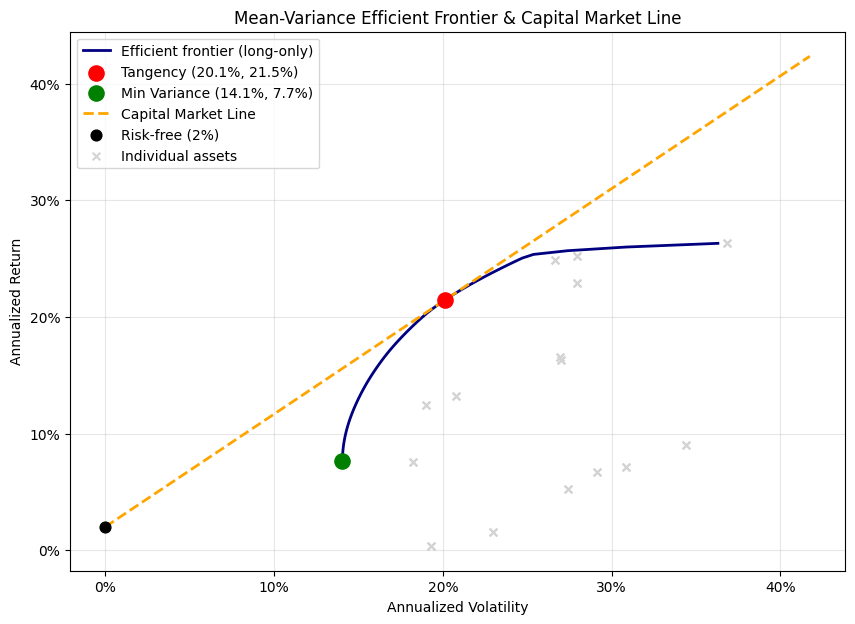

In [8]:
def min_vol_for_target(r_target, mu, cov, bounds, w0):
    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "eq", "fun": lambda w, r=r_target: w @ mu.values - r},
    ]
    res = minimize(
        port_var, w0, args=(cov,),
        method="SLSQP", bounds=bounds, constraints=cons,
        options={"ftol": 1e-10, "maxiter": 500},
    )
    if not res.success:
        return np.nan
    return float(np.sqrt(res.fun))


n_points = 60
r_grid = np.linspace(mvp_ret, mu_hat.max() * 0.999, n_points)
sigma_grid = np.array([min_vol_for_target(r, mu_hat, cov_hat, bounds, w0) for r in r_grid])

plt.figure(figsize=(10, 7))
plt.plot(sigma_grid, r_grid, color="navy", linewidth=2, label="Efficient frontier (long-only)")
plt.scatter([tan_vol], [tan_ret], color="red", s=120, zorder=5,
            label=f"Tangency ({tan_vol:.1%}, {tan_ret:.1%})")
plt.scatter([mvp_vol], [mvp_ret], color="green", s=120, zorder=5,
            label=f"Min Variance ({mvp_vol:.1%}, {mvp_ret:.1%})")

# Capital Market Line: tangent from (0, rf) through tangency portfolio.
cml_x = np.linspace(0.0, float(np.nanmax(sigma_grid)) * 1.15, 100)
cml_y = RF_ANNUAL + (tan_ret - RF_ANNUAL) / tan_vol * cml_x
plt.plot(cml_x, cml_y, color="orange", linestyle="--", linewidth=2, label="Capital Market Line")
plt.scatter([0.0], [RF_ANNUAL], color="black", s=60, zorder=5, label=f"Risk-free ({RF_ANNUAL:.0%})")

# Individual assets for context.
plt.scatter(np.sqrt(np.diag(cov_hat.values)), mu_hat.values,
            color="lightgray", s=30, marker="x", label="Individual assets")

plt.title("Mean-Variance Efficient Frontier & Capital Market Line")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

## Section 5 — Two-asset frontier vs correlation

We pick one high-return / high-volatility name and one low-return / low-volatility name from the universe to make the diversification effect visible. We then vary the correlation over ρ ∈ {-1, -0.5, 0, 0.3, 1} while holding each asset's own μ and σ fixed.

High-return asset:  META UW Equity.1   mu=26.34%  sigma=36.82%
Low-risk  asset:    PG UN Equity   mu=7.56%  sigma=18.25%
Empirical correlation: 0.229


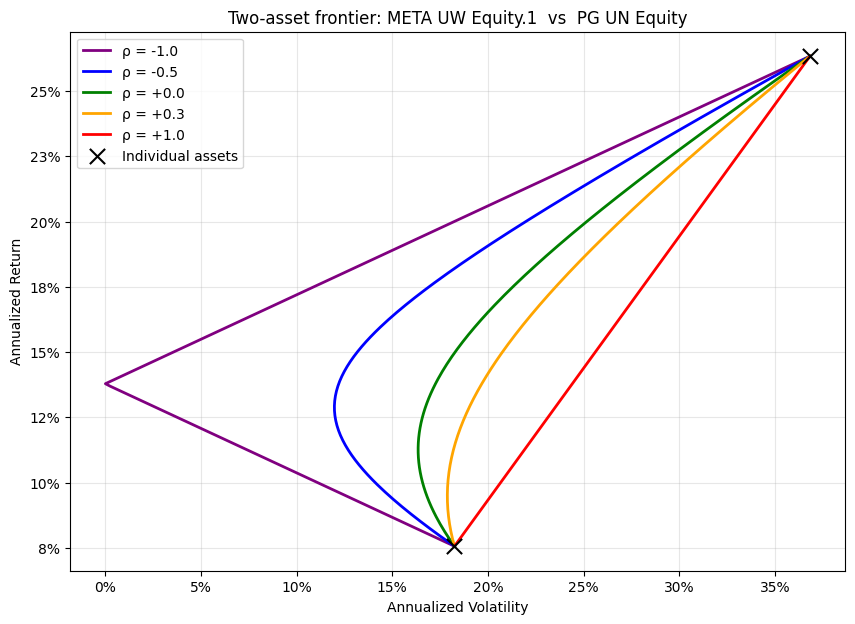


Analytic check (rho=-1): w* = 0.3314, sigma at w* = 1.39e-17


In [9]:
sigmas = pd.Series(np.sqrt(np.diag(cov_hat.values)), index=selected)

# High-return pick and low-risk pick, both drawn from our universe.
asset_hi = mu_hat.idxmax()
asset_lo = sigmas.idxmin()

mu1, mu2 = float(mu_hat[asset_hi]), float(mu_hat[asset_lo])
s1, s2 = float(sigmas[asset_hi]), float(sigmas[asset_lo])
rho_empirical = float(cov_hat.loc[asset_hi, asset_lo] / (s1 * s2))

print(f"High-return asset:  {asset_hi}   mu={mu1:.2%}  sigma={s1:.2%}")
print(f"Low-risk  asset:    {asset_lo}   mu={mu2:.2%}  sigma={s2:.2%}")
print(f"Empirical correlation: {rho_empirical:.3f}")

correlations = [-1.0, -0.5, 0.0, 0.3, 1.0]
colors = ["purple", "blue", "green", "orange", "red"]

w_grid = np.linspace(0.0, 1.0, 200)
plt.figure(figsize=(10, 7))
for rho, color in zip(correlations, colors):
    port_mu = w_grid * mu1 + (1 - w_grid) * mu2
    port_var_2 = (w_grid ** 2) * s1 ** 2 + ((1 - w_grid) ** 2) * s2 ** 2 \
        + 2 * w_grid * (1 - w_grid) * rho * s1 * s2
    port_sigma = np.sqrt(np.clip(port_var_2, 0.0, None))
    plt.plot(port_sigma, port_mu, color=color, linewidth=2, label=f"ρ = {rho:+.1f}")

plt.scatter([s1, s2], [mu1, mu2], color="black", marker="x", s=120, zorder=5,
            label="Individual assets")
plt.title(f"Two-asset frontier: {asset_hi}  vs  {asset_lo}")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Analytic sanity check: with rho = -1 the min-vol portfolio touches sigma = 0 at
# w* = s2 / (s1 + s2).
w_star = s2 / (s1 + s2)
sigma_at_wstar_rho_m1 = abs(w_star * s1 - (1 - w_star) * s2)
print(f"\nAnalytic check (rho=-1): w* = {w_star:.4f}, sigma at w* = {sigma_at_wstar_rho_m1:.2e}")

**Takeaways from the two-asset experiment**

- ρ = +1: the frontier collapses to a straight line between the two asset points — no diversification benefit.
- 0 < ρ < 1: the frontier bows leftward. Lower ρ = more bow = more diversification.
- ρ = 0: classical textbook bow; the minimum-variance combination beats each individual asset on volatility.
- ρ = -0.5: risk is reduced substantially; the frontier nearly touches the y-axis.
- ρ = -1: the two assets perfectly hedge each other; the minimum-variance combination has σ = 0 at `w* = σ₂ / (σ₁ + σ₂)` (verified numerically above).

The practical point: diversification value comes from imperfect correlation, and the marginal benefit grows as ρ falls.